In [1]:
from typing import Dict,TypedDict,List,Annotated,Sequence,Literal
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import AIMessage,SystemMessage,BaseMessage
from langchain_core.tools import tool
from sklearn.cluster import DBSCAN
from langchain_groq import ChatGroq
import pandas as pd
from langgraph.graph import add_messages
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode
from enum import Enum
load_dotenv()

True

In [2]:
class AgentState(TypedDict):
    RegionName : Annotated[str,"The name of the region we are concerned about"]
    congestion_level : Annotated[Literal['Low','High','Medium'],"This is the level of congestion that that triggered this workflow"]
    queried_congestion_level : Annotated[Literal['Low','High','Medium'],"This is the level of congestion that is queried from the database and will be compared with the one sent from webhook"]
    congestion_confidence : Annotated[float,"This is the how confident the cell tower is about the congestion it made"]
    webhook_payload: Annotated[dict,"A"] # this is to be replaces by what is returned from the webhook
    geofenced_locations : Annotated[list[list[float]],"This is going to be a 2 column array having the lat and long of all the locations retreived from the location retreival api"]
    clusters_centers : Annotated[list[List[float]],"The center of each cluster after the DBSCAN was run on the geofenced locations"]
    Random_sample_numbers : Annotated[list[str],"This is the random sample of phone numbers queried from the DB"]
    messages: Annotated[Sequence[str],add_messages]
    AIResponse : Annotated[Literal['continue'],Literal['end'],"The response the ai will give us"]

In [3]:
class DataBaseModel(TypedDict):
    RegionName: Annotated[str,"Name of the smart city"]
    congestion_level: Annotated[Literal['Low','High','Medium'],"The level of congestion for the queried hour"]

In [4]:
@tool
def Region_condition_query(RegionName :str, time:float) -> AgentState:
    """This tool is specific to querying the database and getting the average congection level for a specific hour in the day"""
    #TODO
    # Query the database and wait for the retreival of the data
    # returned to llm which will reason about the retreived data against the data he has
    pass
    return {'queried_congestion_level':result_of_DB_call}

In [5]:
def Region_number_retreival(state:AgentState)->AgentState:
    """This will query the database and will return X random numbers as a list of numbers used before location retreival"""
    
    regionName = state['RegionName']
    #TODO
    #Generate X random number from 0 to the size of database inclusive and send the query to DB
    # database will return a list of number
    
    return {'Random_sample_numbers':list_of_random_numbers}


In [ ]:

Earth_radius  = 6371.0088
Earth_epsilon = 2 #distance of the region
def location_retrival_api(state:AgentState) -> AgentState:
    """This function need to make an api call to the nokia as code and query about the locations of the 
        random sampled phones generated by the DB
    """
    
    eps_radians = (Earth_epsilon/Earth_radius)
    dbscan_model = DBSCAN(eps=eps_radians, metric='haversine',algorithm='ball_tree')
    
    numbers_list = state['Random_sample_numbers']
    #TODO
    # perform location retreival on all the random numbers and wait for the response
    # now we run the db scan    
    
    list_of_locations_lat = []
    list_of_locations_long = []
    
    # for location in locations:
        # list_of_locations_lat.append(location['lat'])
        # list_of_locations_long.append(location['long'])
    
    # df = pd.dataframe({
    #        "lat":list_of_locations_lat,
    #        "long":list_of_locations_long
    #})
    # df['cluster'] = dbscan_model.fit(np.radians(df[['lat','long']])).labels_
    # clean_clusters =df[df['cluster'!= -1]]
    # result_lat_long = clean_cluster.groupby('cluster')['lat','long'].mean()
    
    return {'clusters_centers',result_lat_long.values.tolist()}

In [ ]:
def SMS_users():
    """This will be responsible for dispatching the user messages to the app so all users are notified"""
    
    #TODO
    # Send the notification to the app this is non blocking just dispatch the worker

In [8]:
def SMS_Admins(Admin_UserName : str):
    """This will be responsible for dispatching the user messages to the app so the specified admin is
        notified
    """
    #TODO
        # Send the notification to the app this is non blocking just dispatch the worker

In [9]:
tools = [Region_condition_query]

In [10]:
model = ChatGroq(
    model="llama-3.3-70b-versatile"
    ,temperature= 0.5,
    reasoning_format='parsed'
    ).bind_tools(tools=tools)

In [11]:
def Brain_node(state:AgentState)->AgentState:
    systemprompt = SystemMessage(content="""
    You are an emergency dispatch decision maker for a smart city. 
    You will receive real-time congestion alerts.
    
    Step 1: Always use the Region_condition_query tool to find the historical average congestion and population for the region.
    Step 2: Compare the real-time alert against the historical data. 
    Step 3: If the real-time congestion severely exceeds the historical average and poses a danger, respond ONLY with the word "continue". Otherwise, respond ONLY with the word "end".
""")
    
    if(not state['queried_congestion_level']):
        return {'messages':systemprompt}
    else:
        response = model.invoke("".join(state['messages']) + " confidence of the sent stress: " + str(state['congestion_confidence'])
                    + " Average congestion level " + str(state['queried_congestion_level'])
                    )
        if "continue" in response.content:
            return {'AIResponse':"continue"}
        else:
            return {'AIResponse':"end"}
        
            


In [12]:
def Dispatching_Decision(state:AgentState)-> str:
    last_message = state['messages'][-1]
    
    # 1. Did the LLM decide to call our database tool?
    if hasattr(last_message, 'tool_calls') and len(last_message.tool_calls) > 0:
        return "query"
        
    # 2. If no tool was called, evaluate the final text response
    if "continue" in last_message.content.lower():
        return "continue"
    else:
        return "end"

In [13]:
def dispatch_SMS(state:AgentState):
    pass

In [14]:
graph = StateGraph(AgentState)
Tool = ToolNode(tools = tools)
graph.add_node("query",Tool)
graph.add_node("agent",Brain_node)
graph.add_node("region_number_retreival",Region_number_retreival)
graph.add_node("location_retrival_api",location_retrival_api)
graph.add_node("dispatch_SMS",dispatch_SMS)


graph.add_edge(START,"agent")
graph.add_conditional_edges(
    "agent"
    ,Dispatching_Decision,
    {
     "end":END,
     "continue":"region_number_retreival",
    "query":"query"
    }
)
graph.add_edge("query","agent")
graph.add_edge("region_number_retreival","location_retrival_api")
graph.add_edge("location_retrival_api","dispatch_SMS")
graph.add_edge("dispatch_SMS",END)

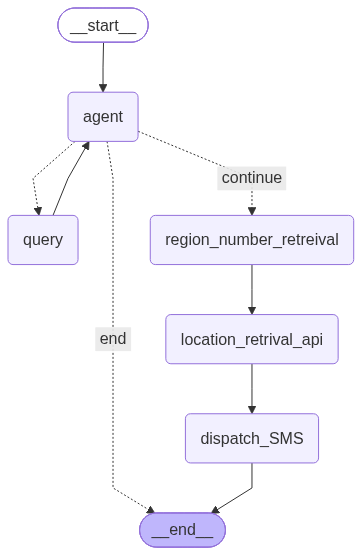

In [15]:
from IPython.display import Image ,display

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))